# Heart Attack Prediction Analysis

This notebook analyzes a heart attack dataset, visualizes feature correlations, and evaluates multiple machine learning models to predict heart attack risk.

## Import Libraries

First, we'll import the necessary libraries for data analysis and visualization.

In [33]:
# ---------------------
# CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
# ---------------------

## Load the Dataset

Load the heart attack dataset from the CSV file and display basic information about it.

In [34]:
# Import the dataset by using pandas
# ---------------------
# CODE HERE
df = pd.read_csv('Heart_Attack.csv') 
# ---------------------


# Display the first 5 rows of the dataset
# ---------------------
# CODE HERE
df.head()
# ---------------------

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [35]:
# Display the statistical information of the dataset
# ---------------------
# CODE HERE
df.describe()
# ---------------------

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Data Cleaning
Check for missing values and handle them if necessary.

In [36]:
# Data Cleaning
# ---------------------
# CODE HERE
# 1. Check for missing values
print("Missing values in each column:\n", df.isnull().sum())

# 2. Check and remove duplicates
print("\nNumber of duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Number of duplicate rows after:", df.duplicated().sum())
# ---------------------

Missing values in each column:
 age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

Number of duplicate rows before: 1
Number of duplicate rows after: 0


## Correlation Analysis

Calculate and display the correlation matrix to understand relationships between variables.

In [37]:
# Calculate the correlation of the dataset
# Save the result in a variable called corr
corr = df.corr()

## Visualize Correlation Matrix

Create a heatmap to visualize the correlation between features.

C:\Users\User\AppData\Local\Temp\ipykernel_37824\1167481190.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(df.columns)
C:\Users\User\AppData\Local\Temp\ipykernel_37824\1167481190.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  text = ax.text(j, i, round(corr.iloc[i][j],2),


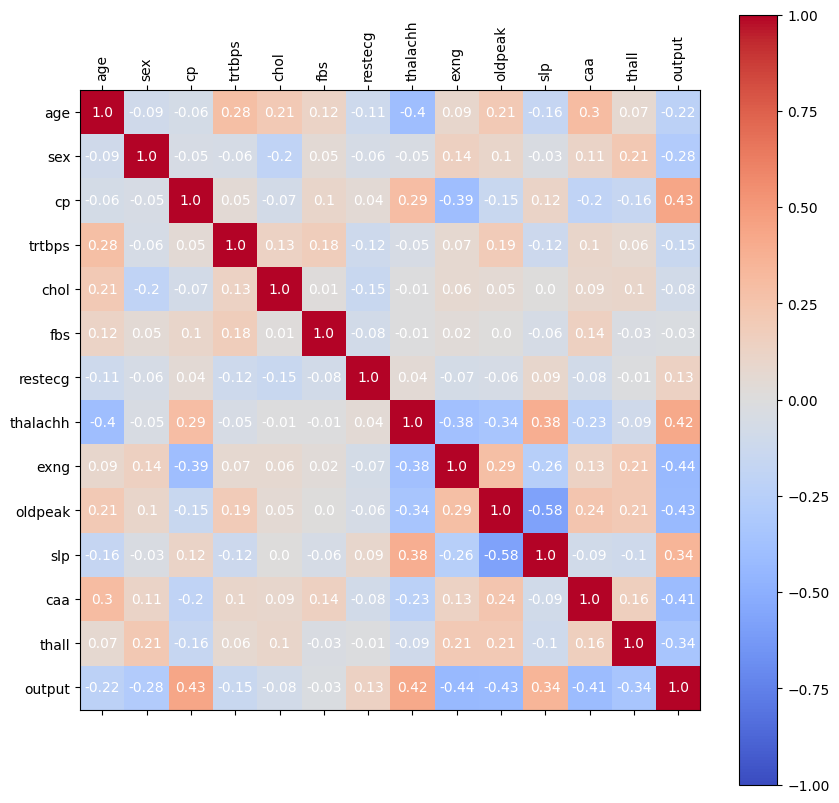

In [38]:
# Plot the correlation matrix (corr) using seaborn
fig, ax = plt.subplots(figsize=(10, 10))
cax = ax.matshow(corr,cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(0,len(df.columns),1)
ax.set_xticks(ticks)
ax.set_xticklabels(df.columns)
plt.xticks(rotation = 90)
ax.set_yticklabels(df.columns)
ax.set_yticks(ticks)
#---print the correlation factor---
for i in range(df.shape[1]):
    for j in range(df.shape[1]):
        text = ax.text(j, i, round(corr.iloc[i][j],2),
        ha="center", va="center", color="w")
plt.show()

## Feature Selection and Target Variable

Select the most relevant features for our model and define the target variable.
<br>Note. For this task we will choose 4 features.

In [39]:
# Split the dataset into X and y
# X contains the selected columns
# y contains the target column
# ---------------------
# CODE HERE
features = ['cp', 'thalachh', 'exng', 'oldpeak'] #Correlation บอกเราว่าตัวแปรนั้นมี "แรงดึงดูด" ต่อ output มากแค่ไหน
X = df[features]
y = df['output']
# ---------------------

## Data Preprocessing: Feature Scaling (Optional)

Standardize the features to have mean=0 and variance=1, which is important for many ML algorithms.
<br>Note. If you use this Data Preprocessing step, you should also apply it to the prediction step as well.

In [40]:
# Data Preprocessing (optional)
# ---------------------
# CODE HERE
from sklearn.preprocessing import StandardScaler
# ---------------------
# CODE HERE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Model Evaluation Using Cross-Validation

We'll evaluate multiple machine learning models using 10-fold cross-validation to find the best performer.
<br>Note. The train/test split is not necessary when using cross-validation because the data is split into training and testing sets multiple times.

In [41]:
# Import the cross_val_score from sklearn
from sklearn.model_selection import cross_val_score

### Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression

# 1. สร้างตัวโมเดล Logistic Regression
logRe = LogisticRegression()
# 2. ใช้ cross_val_score โดยส่ง (โมเดล, ข้อมูล X, ข้อมูล y, จำนวนรอบที่ต้องการทดสอบ, และเกณฑ์การวัดผล)
# แนะนำให้ใช้ cv=10 และ scoring='accuracy' ครับ
logRe_score = cross_val_score(logRe, X_scaled, y, cv=10, scoring='accuracy').mean()
print('LogisticRegression Accuracy:', logRe_score)

LogisticRegression Accuracy: 0.7949462365591398


### K-Nearest Neighbors

Test different values of k to find the optimal number of neighbors.

In [43]:
from sklearn.neighbors import KNeighborsClassifier

# กำหนด folds ถ้ายังไม่ได้กำหนดใน Cell ก่อนหน้า
folds = 10

cv_scores = []
ks = list(range(1, int(len(X) * ((folds - 1)/folds)), 2))
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_scaled, y, cv=folds, scoring='accuracy').mean()
    cv_scores.append(score)
knn_score = max(cv_scores)
optimal_k = ks[cv_scores.index(knn_score)]
print('kNN',(optimal_k,knn_score))

kNN (89, np.float64(0.7947311827956989))


### Decision Tree

Test different tree depths to find the optimal complexity.

In [44]:
from sklearn.tree import DecisionTreeClassifier

# folds = 10

depth = []
for i in range(3, 20):
    # 1. สร้างตัวโมเดล DecisionTree โดยกำหนด max_depth ตามรอบของลูป
    clf = DecisionTreeClassifier(max_depth=i)
    
    # 2. ใช้ cross_val_score กับ X_scaled และ y
    # n_jobs=4 ช่วยให้ประมวลผลเร็วขึ้นโดยใช้ CPU หลาย Core
    scores = cross_val_score(clf, X_scaled, y, cv=folds, n_jobs=4)
    
    depth.append([i, scores.mean()])

# คำนวณหาค่า Depth ที่ให้ผลลัพธ์ดีที่สุด
depth = np.array(depth)
d = depth[np.argmax(depth[:,1], axis=0), 0] # ได้ค่า Depth (d)
s = depth[np.argmax(depth[:,1], axis=0), 1] # ได้ค่า Accuracy (s)

print('Decision Tree (Optimal Depth, Accuracy):', (d, s))

Decision Tree (Optimal Depth, Accuracy): (np.float64(4.0), np.float64(0.7548387096774194))


### Support Vector Machines

Test SVM with different kernels: linear and radial basis function (RBF).

In [45]:
from sklearn import svm

# folds = 10

# 1. Linear kernel
linear_svm = svm.SVC(kernel='linear')
linear_svm_score = cross_val_score(linear_svm, X_scaled, y, cv=folds, scoring='accuracy').mean()
print('SVM-Linear Accuracy:', linear_svm_score)

# 2. RBF kernel
rbf_svm = svm.SVC(kernel='rbf')
rbf_svm_score = cross_val_score(rbf_svm, X_scaled, y, cv=folds, scoring='accuracy').mean()
print('SVM-RBF Accuracy:', rbf_svm_score)


SVM-Linear Accuracy: 0.8046236559139786
SVM-RBF Accuracy: 0.771505376344086


### Random Forest

In [46]:
from sklearn.ensemble import RandomForestClassifier

# 1. สร้างตัวโมเดล RandomForest
rf = RandomForestClassifier()

# 2. ใช้ cross_val_score เพื่อวัดความแม่นยำ
rf_score = cross_val_score(rf, X_scaled, y, cv=folds, scoring='accuracy').mean()

print('Random Forest Accuracy:', rf_score)


Random Forest Accuracy: 0.7418279569892474


# Conclusion

In [50]:
# สร้าง Dictionary เก็บชื่อโมเดลและคะแนนที่ได้
scores = {
    'Logistic Regression': logRe_score,
    'KNN': knn_score,
    'Decision Tree': s,
    'SVM-Linear': linear_svm_score,
    'SVM-RBF': rbf_svm_score,
    'Random Forest': rf_score
}
# หาชื่อโมเดลที่ดีที่สุด (ที่มีคะแนนสูงสุด)
best_model = max(scores, key=scores.get)
print(f'Best model is {best_model} with accuracy of {scores[best_model]:.4f}')
# ---------------------

Best model is SVM-Linear with accuracy of 0.8046


## Train and Save the Best Model

Based on the evaluation, we'll train the Logistic Regression model on the full dataset and save it for future use.

In [48]:
import pickle

# Train the final model using the best algorithm
# In this case, we will use the whole dataset to train the model
# and save the model to disk
# ---------------------
# CODE HERE
# 1. เทรนโมเดล Logistic Regression ด้วยข้อมูลทั้งหมด (X_scaled และ y)
final_model = LogisticRegression()
final_model.fit(X_scaled, y)
# 2. บันทึกตัวโมเดลลงไฟล์ชื่อ 'model.pk'
with open('model.pk', 'wb') as model_file:
    pickle.dump(final_model, model_file)
# ---------------------



Save the model to a file using the pickle library.

In [49]:
# Save the model to disk
# ---------------------
# CODE HERE
# 3. บันทึกตัว Scaler ลงไฟล์ชื่อ 'scaler.pk' 
# (สำคัญมาก! ต้องบันทึกตัวที่ใช้ fit_transform ข้อมูล X มา)
with open('scaler.pk', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)
# ---------------------

print("บันทึกโมเดลและ Scaler เรียบร้อยแล้ว! (model.pk, scaler.pk)")

บันทึกโมเดลและ Scaler เรียบร้อยแล้ว! (model.pk, scaler.pk)
